In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model.parameters import *
from modules.transitory_functions import *
from scipy.optimize import approx_fprime


In [2]:
class plant:
    def __init__(self):

        self.state_name = ["C_O2_ccl", "C_v_ccl", "s_ccl", "lambda_ccl"]
        self.gradient = {}
        for name in self.state_name:
            self.gradient["d" + name + " / dt"] = 0
        # Set points
        self.P_des = 1.5e5  # Pa
        self.T_des = 333.15  # K
        self.Phi_des = 0.5 # -
        self.Sc_des = 2.5  # -
        self.i_fc = 0.5e4  # A/m2
        # Variables
        self.t = 0
        self.Tccl = 60 + 273.15  # K
        self.Pccl = 0
        self.Pcgdl = 0
        self.C_N2 = self.P_des / (R * self.T_des) - Psat(self.T_des) * 0.79  # mol/m3
        self.C_O2_cgc = 8.22  # mol/m3
        self.C_v_cgc =  self.Phi_des * Psat(self.Tccl)/(R * self.Tccl)  # mol/m3
        self.C_v_ccl = self.Sc_des*Psat(self.Tccl)

    def dxdt(self, t, variables):
        
        self.dt = t - self.t
        self.t = t
       
        sv = {}
        for i_name in range(len(self.state_name)):
            sv[self.state_name[i_name]] = variables[i_name]

        # Massflow
        # Immediately calculation
        self.Pcgdl = self.P_des
        self.Pccl =  (sv["C_v_ccl"] + sv["C_O2_ccl"] + self.C_N2) * R * self.Tccl
        self.C_N2 = self.P_des - (sv["C_O2_ccl"] + sv["C_v_ccl"]) * (R * self.Tccl)
        Pccl_cgdl = self.Pccl / 2 + self.Pcgdl / 2
        # Material properties
        epsilon_mean = epsilon_gdl / 2 + epsilon_cl / 2
        Dccl = Dc_eff(sv["s_ccl"], epsilon_mean, Pccl_cgdl, self.Tccl, epsilon_c, epsilon_gdl)
        J_O2_ccl_cgdl = -  Dccl * (self.C_O2_cgc - sv["C_O2_ccl"]) / (Hgdl + Hcl)
        Jv_ccl_cgdl = -  Dccl * (self.C_v_cgc - sv['C_v_ccl']) / (Hgdl + Hcl)
        S_O2_ccl = - self.i_fc / (4 * F * Hcl)
        Sp_ccl = self.i_fc / (4 * F * Hcl)
        S_sorp_ccl = gamma_sorp(sv['C_v_ccl'], sv["s_ccl"],  sv["lambda_ccl"], self.Tccl, Hcl, Kshape) * rho_mem / M_eq * \
                               (lambda_eq(sv['C_v_ccl'],sv["s_ccl"], self.Tccl, Kshape) - sv["lambda_ccl"])
        Sl_ccl = Svl(sv["s_ccl"], sv['C_v_ccl'], sv['C_v_ccl'] + sv["C_O2_ccl"] + self.C_N2, epsilon_cl, self.Tccl, gamma_cond, gamma_evap)
        Sv_ccl = - Sl_ccl 
        # Mass flow of vapor at CCL
        self.gradient['dC_v_ccl / dt'] = 1 / (epsilon_cl * (1 - sv["s_ccl"])) * (- Jv_ccl_cgdl / Hcl - S_sorp_ccl + Sv_ccl)
        self.gradient['dC_O2_ccl / dt'] = 1 / (epsilon_cl * (1 - sv["s_ccl"])) * (-J_O2_ccl_cgdl / Hcl + S_O2_ccl)
        self.gradient["ds_ccl / dt"] = 1 / (rho_H2O(self.Tccl) * epsilon_cl) * (M_H2O * Sl_ccl)
        self.gradient["dlambda_ccl / dt"] = M_eq / (rho_mem * epsilon_mc) * (S_sorp_ccl + Sp_ccl)

        return list(self.gradient.values())
    
    def getUcell(self, s_ccl, lambda_ccl, lambda_mem, C_O2_ccl):
        
        Re = 5.70e-7  # ohm.m². It is the electron conduction resistance of the circuit.
        i0_c_ref = 2.49  # A.m-2.It is the reference exchange current density at the cathode.
        kappa_c = 1.61  # It is the overpotential correction exponent.
        # The equilibrium potential
        Ueq = 1.18 
        # The proton resistance
        # The proton resistance at the membrane : Rmem
        if lambda_mem >= 1:
            Rmem = Hmem / ((0.5139 * lambda_mem - 0.326) * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        else:
            Rmem = Hmem / (0.1879 * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        #  The proton resistance at the cathode catalyst layer : Rccl
        if lambda_ccl >= 1:
            Rccl = Hcl / ((epsilon_mc ** tau) * (0.5139 * lambda_ccl - 0.326) * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        else:
            Rccl = Hcl / ((epsilon_mc ** tau) * 0.1879 * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        #  The total proton resistance
        Rp = Rmem + Rccl  # its value is around [4-7]e-6 ohm.m².
        slim = a_slim * (self.P_des / 1e5) + b_slim
        s_switch = a_switch * slim
        f_drop = 0.5 * (1.0 - np.tanh((4 * s_ccl - 2 * slim - 2 * s_switch) / (slim - s_switch)))
        eta_c = 1 / f_drop * R * self.Tccl / (alpha_c * F) * np.log(self.i_fc / i0_c_ref * (C_O2ref / C_O2_ccl) ** kappa_c)
        # The cell voltage
        return Ueq - self.i_fc * (Rp + Re) - eta_c

    def Y(self, x):
            
        sv = {}
        for i_name in range(len(self.state_name)):
            sv[self.state_name[i_name]] = x[i_name]
        self.Ucell = self.getUcell(s_ccl = sv["s_ccl"], lambda_ccl = sv["lambda_ccl"], lambda_mem = sv["lambda_ccl"], C_O2_ccl = sv["C_O2_ccl"])

        return [self.Ucell]

In [3]:
class LuenbergerObserver:
    """
    Second-order Luenberger observer for 
    [C_O2_ccl, C_v_ccl, s_ccl, lambda_ccl] state estimation
    """
    def __init__(self, plant, L: np.ndarray, initial_state: np.ndarray):
        """
        Initialize the Luenberger observer.
        Args:
            plant: Reference to the plant model
            initial_state: Initial state estimate [C_O2_ccl, C_v_ccl, s_ccl, lambda_ccl]
            Observer gain matrix - corrects both states based on output error
        """
        self.plant = plant
        self.L = np.array(L).reshape(len(initial_state), 1)  # Observer gain matrix (4x1)
        self.x_hat = np.array(initial_state).reshape(len(initial_state), 1)  # Estimated state [C_O2_ccl, C_v_ccl, s_ccl, lambda_ccl]
        self.x_new = self.x_hat.copy()
        self.t_prev = 0
    
    def update(self, t, y_measured, u=None):
        """
        Update state estimate based on measured output and input.
        
        Args:
            t: Current time
            y_measured: Measured output (Ucell) - scalar
            u: Input (i_fc) - scalar or None (uses plant.i_fc if None)
        
        Returns:
            x_hat: Current state estimate [C_O2_ccl, C_v_ccl]
        """
        dt = t - self.t_prev
        self.t_prev = t
        
        # Set input if provided
        if u is not None:
            self.plant.i_fc = u
        
        # Get plant dynamics with estimated state
        x_hat_list = self.x_hat.flatten().tolist()
        dx_hat = np.array(self.plant.dxdt(t, x_hat_list)).reshape(len(x_hat_list), 1)
        
        # Get predicted output from estimated state
        y_predicted = self.plant.Y(x_hat_list)[0]
        
        # Observer correction term
        innovation = y_measured - y_predicted  # Scalar
        
        # Observer dynamics: dx_hat/dt = f(x_hat, u) + L*(y_measured - y_predicted)
        # Euler integration with correction
        self.x_new = self.x_hat + dt * dx_hat
        self.x_hat = self.x_new + self.L * innovation
        
        return self.x_hat.copy()
    
    
    def get_estimate(self):
        """Get current state estimate"""
        return self.x_hat.copy()
    
    def set_gain(self, L: np.ndarray):
        """Update observer gain matrix"""
        self.L = np.array(L).reshape(len(self.x_hat), 1)

In [4]:
# Simulation parameters
t_final = 0.001
t_sim = np.linspace(0,t_final, int(t_final/1e-6))  # 2 ms simulation
dt = t_sim[1] - t_sim[0]

# Initialize plant and observer
plant = plant()
observer_gain = np.array([[1], [10], [1e-4], [2]])  # Gain for [C_O2_ccl, C_v_ccl, s_ccl, lambda_ccl]
initial_estimate = np.array([[8.0], [2.0], [1e-4], [0.1]])  # Initial estimate [C_O2_ccl, C_v_ccl, s_ccl, lambda_ccl]
LO = LuenbergerObserver(plant, L=observer_gain, initial_state=initial_estimate)

# Storage for results
time_log = []
state_estimated_O2 = []
state_estimated_v = []
state_estimated_s = []
state_estimated_lambda = []
output_measured = []
output_predicted = []
innovation_log = []
observability_matrices = []
observability_ranks = []

# Constant measured current density
plant.i_fc = 0.2e4  # A/m2

# Initial log
time_log.append(0)
state_estimated_O2.append(initial_estimate[0, 0])
state_estimated_v.append(initial_estimate[1, 0])
state_estimated_s.append(initial_estimate[2, 0])
state_estimated_lambda.append(initial_estimate[3, 0])
y_measured_initial = 0.76  # Initial measured output
output_measured.append(y_measured_initial)
output_predicted.append(plant.Y(initial_estimate.flatten().tolist())[0])
innovation_log.append(y_measured_initial - output_predicted[0])

# Function to compute observability matrix using Lie derivatives with numerical Jacobian
def compute_observability_matrix_lie(plant, x_hat, epsilon=1e-8):

    """
    Compute observability matrix O = [dh/dx; dL_f(h)/dx] using Lie derivatives
    with numerical Jacobian computation using scipy.optimize.approx_fprime
    where:
    - h(x) is the output function
    - L_f(h) is the Lie derivative of h along f (= dh/dx * f(x))
    """
    x = x_hat.flatten()
    n = len(x)
    
    # Define output function
    def output_func(x_vec):
        return plant.Y(x_vec.tolist())[0]
    
    # Compute Jacobian dh/dx using scipy's approx_fprime
    dh_dx = np.zeros((1, n))
    for i in range(n):
        epsilon_vec = np.zeros(n)
        epsilon_vec[i] = epsilon
        dh_dx[0, i] = approx_fprime(x, output_func, epsilon_vec)[i]
    
    # Compute f(x) - the system dynamics
    f_x = np.array(plant.dxdt(plant.t, x.tolist()))
    
    # Compute Lie derivative L_f(h) = dh/dx * f(x)
    L_f_h = np.dot(dh_dx, f_x)[0]
    
    # Define Lie derivative function
    def lie_derivative_func(x_vec):
        # Compute dh/dx at this point
        dh_dx_local = np.zeros(n)
        for i in range(n):
            epsilon_vec = np.zeros(n)
            epsilon_vec[i] = epsilon
            dh_dx_local[i] = approx_fprime(x_vec, output_func, epsilon_vec)[i]
        # Compute f(x) at this point
        f_x_local = np.array(plant.dxdt(plant.t, x_vec.tolist()))
        # Return L_f(h)
        return np.dot(dh_dx_local, f_x_local)
    
    # Compute Jacobian of Lie derivative: dL_f(h)/dx using approx_fprime
    dL_f_h_dx = np.zeros((1, n))
    for i in range(n):
        epsilon_vec = np.zeros(n)
        epsilon_vec[i] = epsilon
        dL_f_h_dx[0, i] = approx_fprime(x, lie_derivative_func, epsilon_vec)[i]
    
    # Observability matrix O = [dh/dx; dL_f(h)/dx]
    O = np.vstack([dh_dx, dL_f_h_dx])
    
    return O, dh_dx, dL_f_h_dx, L_f_h

# Initial observability matrix
O_initial, dh_dx_initial, dL_f_h_dx_initial, L_f_h_initial = compute_observability_matrix_lie(plant, initial_estimate)
observability_matrices.append(O_initial)
observability_ranks.append(np.linalg.matrix_rank(O_initial))

# Run simulation
for t in t_sim:

    # Get measured output
    y_measured = [0.76]
    # Update observer with measurement and input
    x_hat = LO.update(t, y_measured, u=plant.i_fc)
    y_predicted = plant.Y(x_hat.flatten().tolist())[0]
    # Compute observability matrix at current state using Lie derivatives
    O, dh_dx, dL_f_h_dx, L_f_h = compute_observability_matrix_lie(plant, x_hat)
    observability_matrices.append(O)
    observability_ranks.append(np.linalg.matrix_rank(O))
    # Store data
    time_log.append(t)
    state_estimated_O2.append(x_hat[0, 0])
    state_estimated_v.append(x_hat[1, 0])
    state_estimated_s.append(x_hat[2, 0])
    state_estimated_lambda.append(x_hat[3, 0])
    output_measured.append(y_measured[0])
    output_predicted.append(y_predicted)
    innovation_log.append(y_measured - y_predicted)


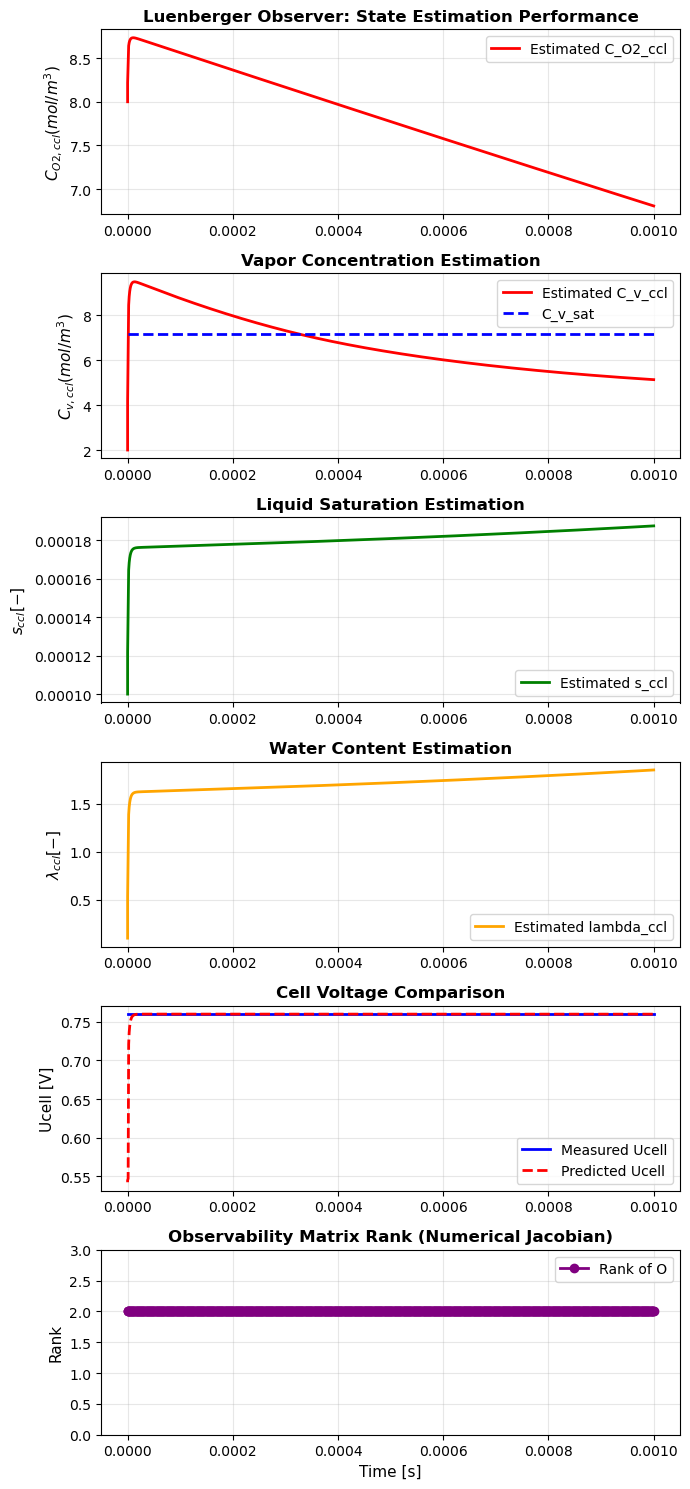

In [6]:
from modules.transitory_functions import C_v_sat
# Plotting
fig, axes = plt.subplots(6, 1, figsize=(7, 15))

# Plot 1: C_O2_ccl estimation
axes[0].plot(time_log, state_estimated_O2, 'r-', linewidth=2, label='Estimated C_O2_ccl')
axes[0].set_ylabel('$C_{O2, ccl} (mol/m^3)$', fontsize=11)
axes[0].set_title('Luenberger Observer: State Estimation Performance', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: C_v_ccl estimation
C_v_sat_values = [C_v_sat(plant.Tccl) for _ in time_log]
axes[1].plot(time_log, state_estimated_v, 'r-', linewidth=2, label='Estimated C_v_ccl')
axes[1].plot(time_log, C_v_sat_values, 'b--', linewidth=2, label='C_v_sat')
axes[1].set_ylabel(r'$C_{v, ccl} (mol/m^3)$', fontsize=11)
axes[1].set_title('Vapor Concentration Estimation', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Plot 3: s_ccl estimation
axes[2].plot(time_log, state_estimated_s, 'g-', linewidth=2, label='Estimated s_ccl')
axes[2].set_ylabel(r'$s_{ccl} [-]$', fontsize=11)
axes[2].set_title('Liquid Saturation Estimation', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

# Plot 4: lambda_ccl estimation
axes[3].plot(time_log, state_estimated_lambda, 'orange', linewidth=2, label='Estimated lambda_ccl')
axes[3].set_ylabel(r'$\lambda_{ccl} [-]$', fontsize=11)
axes[3].set_title('Water Content Estimation', fontsize=12, fontweight='bold')
axes[3].legend(fontsize=10)
axes[3].grid(True, alpha=0.3)

# Plot 5: Output comparison
axes[4].plot(time_log, output_measured, 'b-', linewidth=2, label='Measured Ucell')
axes[4].plot(time_log, output_predicted, 'r--', linewidth=2, label='Predicted Ucell')
axes[4].set_ylabel('Ucell [V]', fontsize=11)
axes[4].set_title('Cell Voltage Comparison', fontsize=12, fontweight='bold')
axes[4].legend(fontsize=10)
axes[4].grid(True, alpha=0.3)

# Plot 6: Observability matrix rank
axes[5].plot(time_log, observability_ranks, 'purple', linewidth=2, marker='o', label='Rank of O')
axes[5].set_ylabel('Rank', fontsize=11)
axes[5].set_xlabel('Time [s]', fontsize=11)
axes[5].set_title('Observability Matrix Rank (Numerical Jacobian)', fontsize=12, fontweight='bold')
axes[5].set_ylim([0, 3])
axes[5].legend(fontsize=10)
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()